In [2]:
import json
import re
import os
import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
import matplotlib.pyplot as plt
from collections import defaultdict

## Inspect a training run

In [13]:
# METRICS_PATH = "output_DVIS_Online_R50_YTVIS22/metrics.json"
METRICS_PATH = "output_DVIS_Online_SwinL_YTVIS22/metrics.json"
# METRICS_PATH = "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_rfdetr_sl_0430/metrics.json"

data = defaultdict(list)
iters = []
with open(METRICS_PATH) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        d = json.loads(line)
        iters.append(d["iteration"])
        for k, v in d.items():
            if k.startswith("loss") or k == "total_loss":
                data[k].append(v)

print(f"Parsed {len(iters)} iterations")
print(f"Keys: {sorted(data.keys())}")

Parsed 1870 iterations
Keys: ['loss_ce', 'loss_ce_0', 'loss_ce_1', 'loss_ce_2', 'loss_ce_3', 'loss_ce_4', 'loss_dice', 'loss_dice_0', 'loss_dice_1', 'loss_dice_2', 'loss_dice_3', 'loss_dice_4', 'loss_mask', 'loss_mask_0', 'loss_mask_1', 'loss_mask_2', 'loss_mask_3', 'loss_mask_4', 'total_loss']


In [14]:
# Separate final-layer vs per-layer losses
final_keys = sorted(k for k in data if not re.search(r"_\d+$", k))
per_layer_keys = sorted(k for k in data if re.search(r"_\d+$", k))

# Group per-layer by loss type (e.g. loss_ce_0..4 -> loss_ce)
loss_types = sorted(set(re.sub(r"_\d+$", "", k) for k in per_layer_keys))

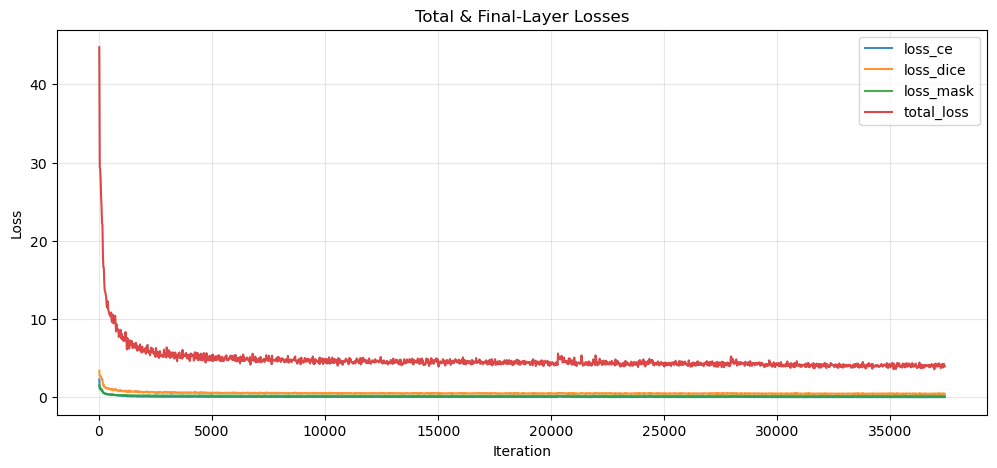

In [15]:
# Plot total + final-layer losses
fig, ax = plt.subplots(figsize=(12, 5))
for key in final_keys:
    ax.plot(iters[:len(data[key])], data[key], label=key, alpha=0.85)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Total & Final-Layer Losses")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

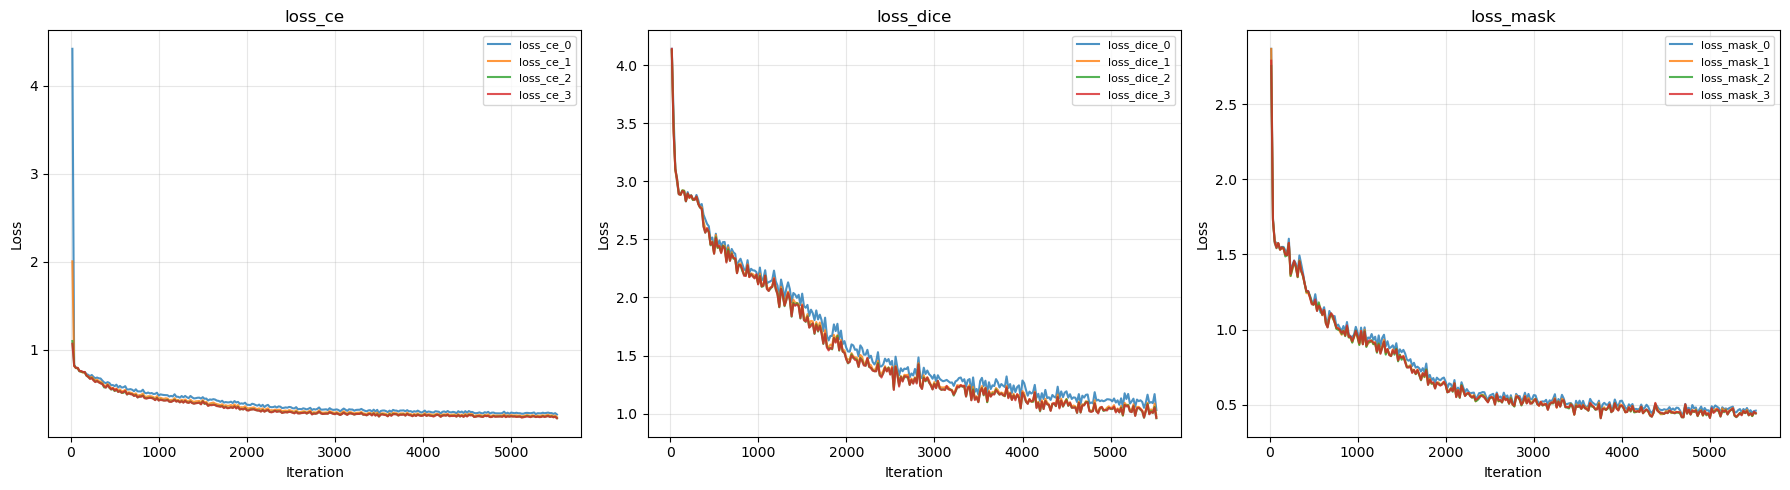

In [59]:
# Plot per-layer losses, one subplot per loss type
fig, axes = plt.subplots(1, len(loss_types), figsize=(6 * len(loss_types), 5))
if len(loss_types) == 1:
    axes = [axes]
for ax, lt in zip(axes, loss_types):
    keys = sorted(k for k in per_layer_keys if k.startswith(lt))
    for key in keys:
        ax.plot(iters[:len(data[key])], data[key], label=key, alpha=0.8)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title(lt)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

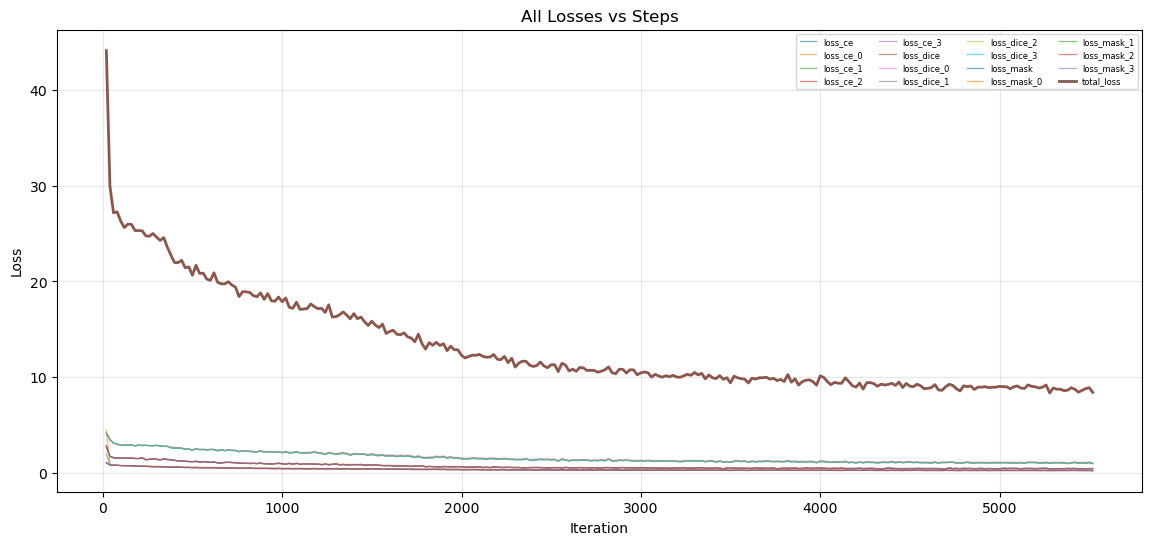

In [60]:
# Plot ALL losses on one figure
fig, ax = plt.subplots(figsize=(14, 6))
all_keys = sorted(data.keys())
for key in all_keys:
    lw = 2.0 if key == "total_loss" else 0.9
    alpha = 1.0 if key == "total_loss" else 0.6
    ax.plot(iters[:len(data[key])], data[key], label=key, linewidth=lw, alpha=alpha)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("All Losses vs Steps")
ax.legend(fontsize=6, ncol=4, loc="upper right")
ax.grid(True, alpha=0.3)
plt.show()

## Compare multiple training runs

In [3]:
def parse_metrics(path):
    """Parse a Detectron2-style metrics.json (one JSON per line) and return (iters, data_dict)."""
    data = defaultdict(list)
    iters = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            d = json.loads(line)
            iters.append(d["iteration"])
            for k, v in d.items():
                if k.startswith("loss") or k == "total_loss":
                    data[k].append(v)
    return iters, data


def plot_total_losses(metrics_paths, labels=None, smoothing=50, figsize=(14, 6)):
    """Plot total_loss from multiple metrics.json files on one figure.

    Args:
        metrics_paths: list of paths to metrics.json files.
        labels: optional list of display names (defaults to filename).
        smoothing: window size for running average (0 to disable).
        figsize: figure size tuple.
    """
    if labels is None:
        labels = [p.split("/")[-2] for p in metrics_paths]

    fig, ax = plt.subplots(figsize=figsize)
    for path, label in zip(metrics_paths, labels):
        iters, data = parse_metrics(path)
        vals = data.get("total_loss", [])
        x = iters[:len(vals)]
        ax.plot(x, vals, alpha=0.25, linewidth=0.5)
        # smoothed line
        if smoothing > 0 and len(vals) >= smoothing:
            import numpy as np
            kernel = np.ones(smoothing) / smoothing
            smoothed = np.convolve(vals, kernel, mode="valid")
            x_smooth = x[smoothing - 1:]
            ax.plot(x_smooth, smoothed, label=label, linewidth=2)
        else:
            ax.plot(x, vals, label=label, linewidth=2)

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Total Loss")
    ax.set_title("Total Loss Comparison")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def display_scores_table(exps):
    rows = []
    for exp_dir in exps:
        scores_path = os.path.join(exp_dir, "eval_results", "scores.txt")
        if not os.path.exists(scores_path):
            print(f"[SKIP] {scores_path} not found")
            continue
        scores = {}
        with open(scores_path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                key, val = line.split(":", 1)
                scores[key.strip()] = float(val.strip())
        scores["experiment"] = exp_dir.rstrip("/").split("/")[-1]
        rows.append(scores)
    
    if rows:
        df = pd.DataFrame(rows)
        # Reorder so experiment name is first
        cols = ["experiment"] + [c for c in df.columns if c != "experiment"]
        df = df[cols]
        display(df)
    else:
        print("No scores.txt found in any experiment.")

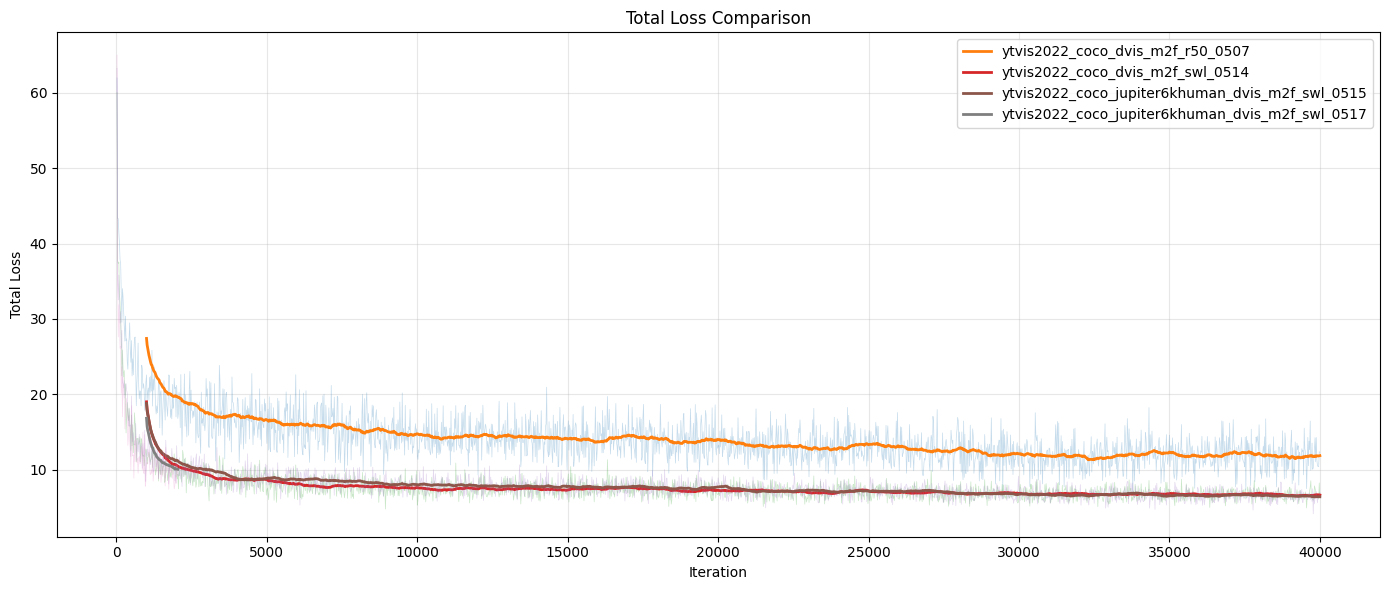

In [18]:
# Example: compare total losses across experiments
exps = [
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_dvis_m2f_r50_0507",  # R50 direct training DVIS
    # "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_dvis_m2f_r50_0508",  # R50 direct training DVIS, batch size 4 to 64
    
    # "output_DVIS_Online_SwinL_YTVIS22/",  # SwinL direct training DVIS
    # "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_dvis_swl_0503/",  # Finetune SwinL on YTVIS first and train DVIS
    # "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_dvis_m2f_swl_0506",  # Finetune SwinL on COCO+YTVIS first and train DVIS
    # "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_dvis_m2f_swl_0508",  # Finetune SwinL on COCO+YTVIS first and train DVIS on COCO+YTVIS
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_dvis_m2f_swl_0514",  # Finetune SwinL on COCO+YTVIS first and train DVIS on COCO+YTVIS
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_jupiter6khuman_dvis_m2f_swl_0515",  # Finetune SwinL on COCO+YTVIS first and train DVIS on COCO+YTVIS+JUPITER6KHUMAN
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_jupiter6khuman_dvis_m2f_swl_0517",  # Finetune SwinL on COCO+YTVIS+JUPITER6KHUMAN first and train DVIS on COCO+YTVIS+JUPITER6KHUMAN

    # "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_rfdetr_sl_0430/",  # RF-DETR direct training DVIS
    # "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_dvis_rfdetr_sl_0506/",  # Finetune RF-DETR on YTVIS first and train DVIS
    # "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_dvis_rfdetr_sl_0507/",  # Finetune RF-DETR on COCO+YTVIS first and train DVIS
    # "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_dvis_rfdetr_sl_0508/",  # Finetune RF-DETR on COCO+YTVIS first and train DVIS on COCO+YTVIS
]
metrics_files = [os.path.join(p, 'metrics.json') for p in exps]

plot_total_losses(metrics_files, smoothing=50)

In [16]:
# Read scores.txt from each experiment and display as a table
exps = [
    "output_Downloaded_DVIS_Online_SwinL_YTVIS21_on_YTVIS22",  # Author released weights
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_dvis_m2f_r50_0507",  # R50 direct training DVIS
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_dvis_m2f_r50_0508",  # R50 direct training DVIS, batch size 4 to 64"output_DVIS_Online_R50_YTVIS22",  # Resnet50 direct training DVIS
    "output_DVIS_Online_SwinL_YTVIS22/",  # SwinL direct training DVIS
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_dvis_swl_0503/",  # Finetune SwinL on YTVIS first and train DVIS
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_dvis_m2f_swl_0506",  # Finetune SwinL on COCO+YTVIS first and train DVIS
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_dvis_m2f_swl_0508",  # Finetune SwinL on COCO+YTVIS first and train DVIS on COCO+YTVIS
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_dvis_m2f_swl_0514",  # Finetune SwinL on COCO+YTVIS first and train DVIS on COCO+YTVIS
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_jupiter6khuman_dvis_m2f_swl_0515",  # Finetune SwinL on COCO+YTVIS first and train DVIS on COCO+YTVIS+JUPITER6KHUMAN

    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_rfdetr_sl_0430/",  # RF-DETR direct training DVIS
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_dvis_rfdetr_sl_0506/",  # Finetune RF-DETR on YTVIS first and train DVIS
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_dvis_rfdetr_sl_0507/",  # Finetune RF-DETR on COCO+YTVIS first and train DVIS
    "/mnt/data2/jupiter/li.yu/exps/driveable_terrain_model/ytvis2022_coco_dvis_rfdetr_sl_0508/",  # Finetune RF-DETR on COCO+YTVIS first and train DVIS on COCO+YTVIS
]
display_scores_table(exps)

,experiment,mAP,mAP_S,AP50_S,AP75_S,AR1_S,AR10_S,mAP_L,AP50_L,AP75_L,AR1_L,AR10_L
0,output_Downloaded_DVIS_Online_SwinL_YTVIS21_on...,0.491,0.586,0.801,0.660,0.474,0.637,0.397,0.583,0.431,0.334,0.445
1,ytvis2022_coco_dvis_m2f_r50_0507,0.347,0.452,0.676,0.498,0.391,0.521,0.242,0.415,0.259,0.201,0.325
2,ytvis2022_coco_dvis_m2f_r50_0508,0.128,0.208,0.314,0.218,0.223,0.263,0.049,0.094,0.032,0.068,0.070
3,output_DVIS_Online_SwinL_YTVIS22,0.267,0.389,0.550,0.436,0.360,0.430,0.146,0.210,0.165,0.131,0.180
4,ytvis2022_dvis_swl_0503,0.226,0.342,0.490,0.372,0.335,0.390,0.109,0.204,0.092,0.109,0.135
5,ytvis2022_dvis_m2f_swl_0506,0.148,0.236,0.402,0.233,0.231,0.290,0.059,0.086,0.076,0.066,0.081
6,ytvis2022_coco_dvis_m2f_swl_0508,0.131,0.219,0.397,0.202,0.208,0.270,0.043,0.089,0.015,0.044,0.071
7,ytvis2022_coco_dvis_m2f_swl_0514,0.468,0.584,0.801,0.661,0.469,0.638,0.351,0.512,0.399,0.321,0.401
8,ytvis2022_coco_jupiter6khuman_dvis_m2f_swl_0515,0.454,0.572,0.790,0.638,0.468,0.630,0.337,0.528,0.358,0.291,0.387
9,ytvis2022_rfdetr_sl_0430,0.025,0.045,0.082,0.038,0.048,0.068,0.005,0.029,0.001,0.004,0.006
